# T.P. — CHA et K-means

**Licence Informatique Paul Sabatier — Module IA — 2023-2024**  
*Emmanuelle Claeys*

---

Ce TP propose une mise en pratique de deux approches de clustering :
- La **Classification Ascendante Hiérarchique (CAH)** avec `scipy` (`linkage`, `dendrogram`)
- La méthode des **K-moyennes (K-means)** avec `scikit-learn` (`KMeans`)

## Imports généraux

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
%matplotlib inline

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from pylab import rcParams

rcParams['figure.figsize'] = 8, 10

---
# 1. Fromages

## 1.1 Chargement des données

Nous traitons d'un ensemble de **29 fromages** caractérisés par leurs propriétés nutritionnelles (**9 variables**).

L'objectif est de déterminer des groupes homogènes de fromages en fonction de leurs propriétés.  
Le fichier `fromage.txt` provient de la page d'enseignement de Marie Chavent (Université de Bordeaux).

### À vous !

**a) Chargez les données dans une variable appelée fromage**

In [3]:
# On lit le document texte 'fromage.txt' avec pour chaque colonnes séparé par une virgule
fromage = pd.read_csv('fromage.txt', sep=',')
fromage.head()

,name,calories,sodium,calcium,lipides,retinol,folates,proteines,cholesterol,magnesium
0,CarredelEst,314,353.5,72.6,26.3,51.6,30.3,21.0,70,20
1,Babybel,314,238.0,209.8,25.1,63.7,6.4,22.6,70,27
2,Beaufort,401,112.0,259.4,33.3,54.9,1.2,26.6,120,41
3,Bleu,342,336.0,211.1,28.9,37.1,27.5,20.2,90,27
4,Camembert,264,314.0,215.9,19.5,103.0,36.4,23.4,60,20


**b) Affichez l'écart-type, la valeur min, max et les quartiles des différentes variables**

In [4]:
fromage.describe()

,calories,sodium,calcium,lipides,retinol,folates,proteines,cholesterol,magnesium
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,300.034483,210.086207,185.734483,24.158621,67.562069,13.010345,20.168966,74.586207,26.965517
std,91.914356,108.678923,72.528882,8.129642,24.163098,11.723339,6.959788,28.245755,11.318388
min,70.000000,22.000000,72.600000,3.400000,37.100000,1.200000,4.100000,10.000000,10.000000
25%,292.000000,140.000000,132.900000,23.400000,51.600000,4.900000,17.800000,70.000000,20.000000
50%,321.000000,223.000000,202.300000,26.300000,62.300000,6.400000,21.000000,80.000000,26.000000
75%,355.000000,276.000000,220.500000,29.100000,76.400000,21.100000,23.400000,90.000000,30.000000
max,406.000000,432.000000,334.600000,33.300000,150.500000,36.400000,35.700000,120.000000,51.000000


**c) Affichez le graph de croisement deux à deux (pairplot)) de la librairie *sea-born*.**

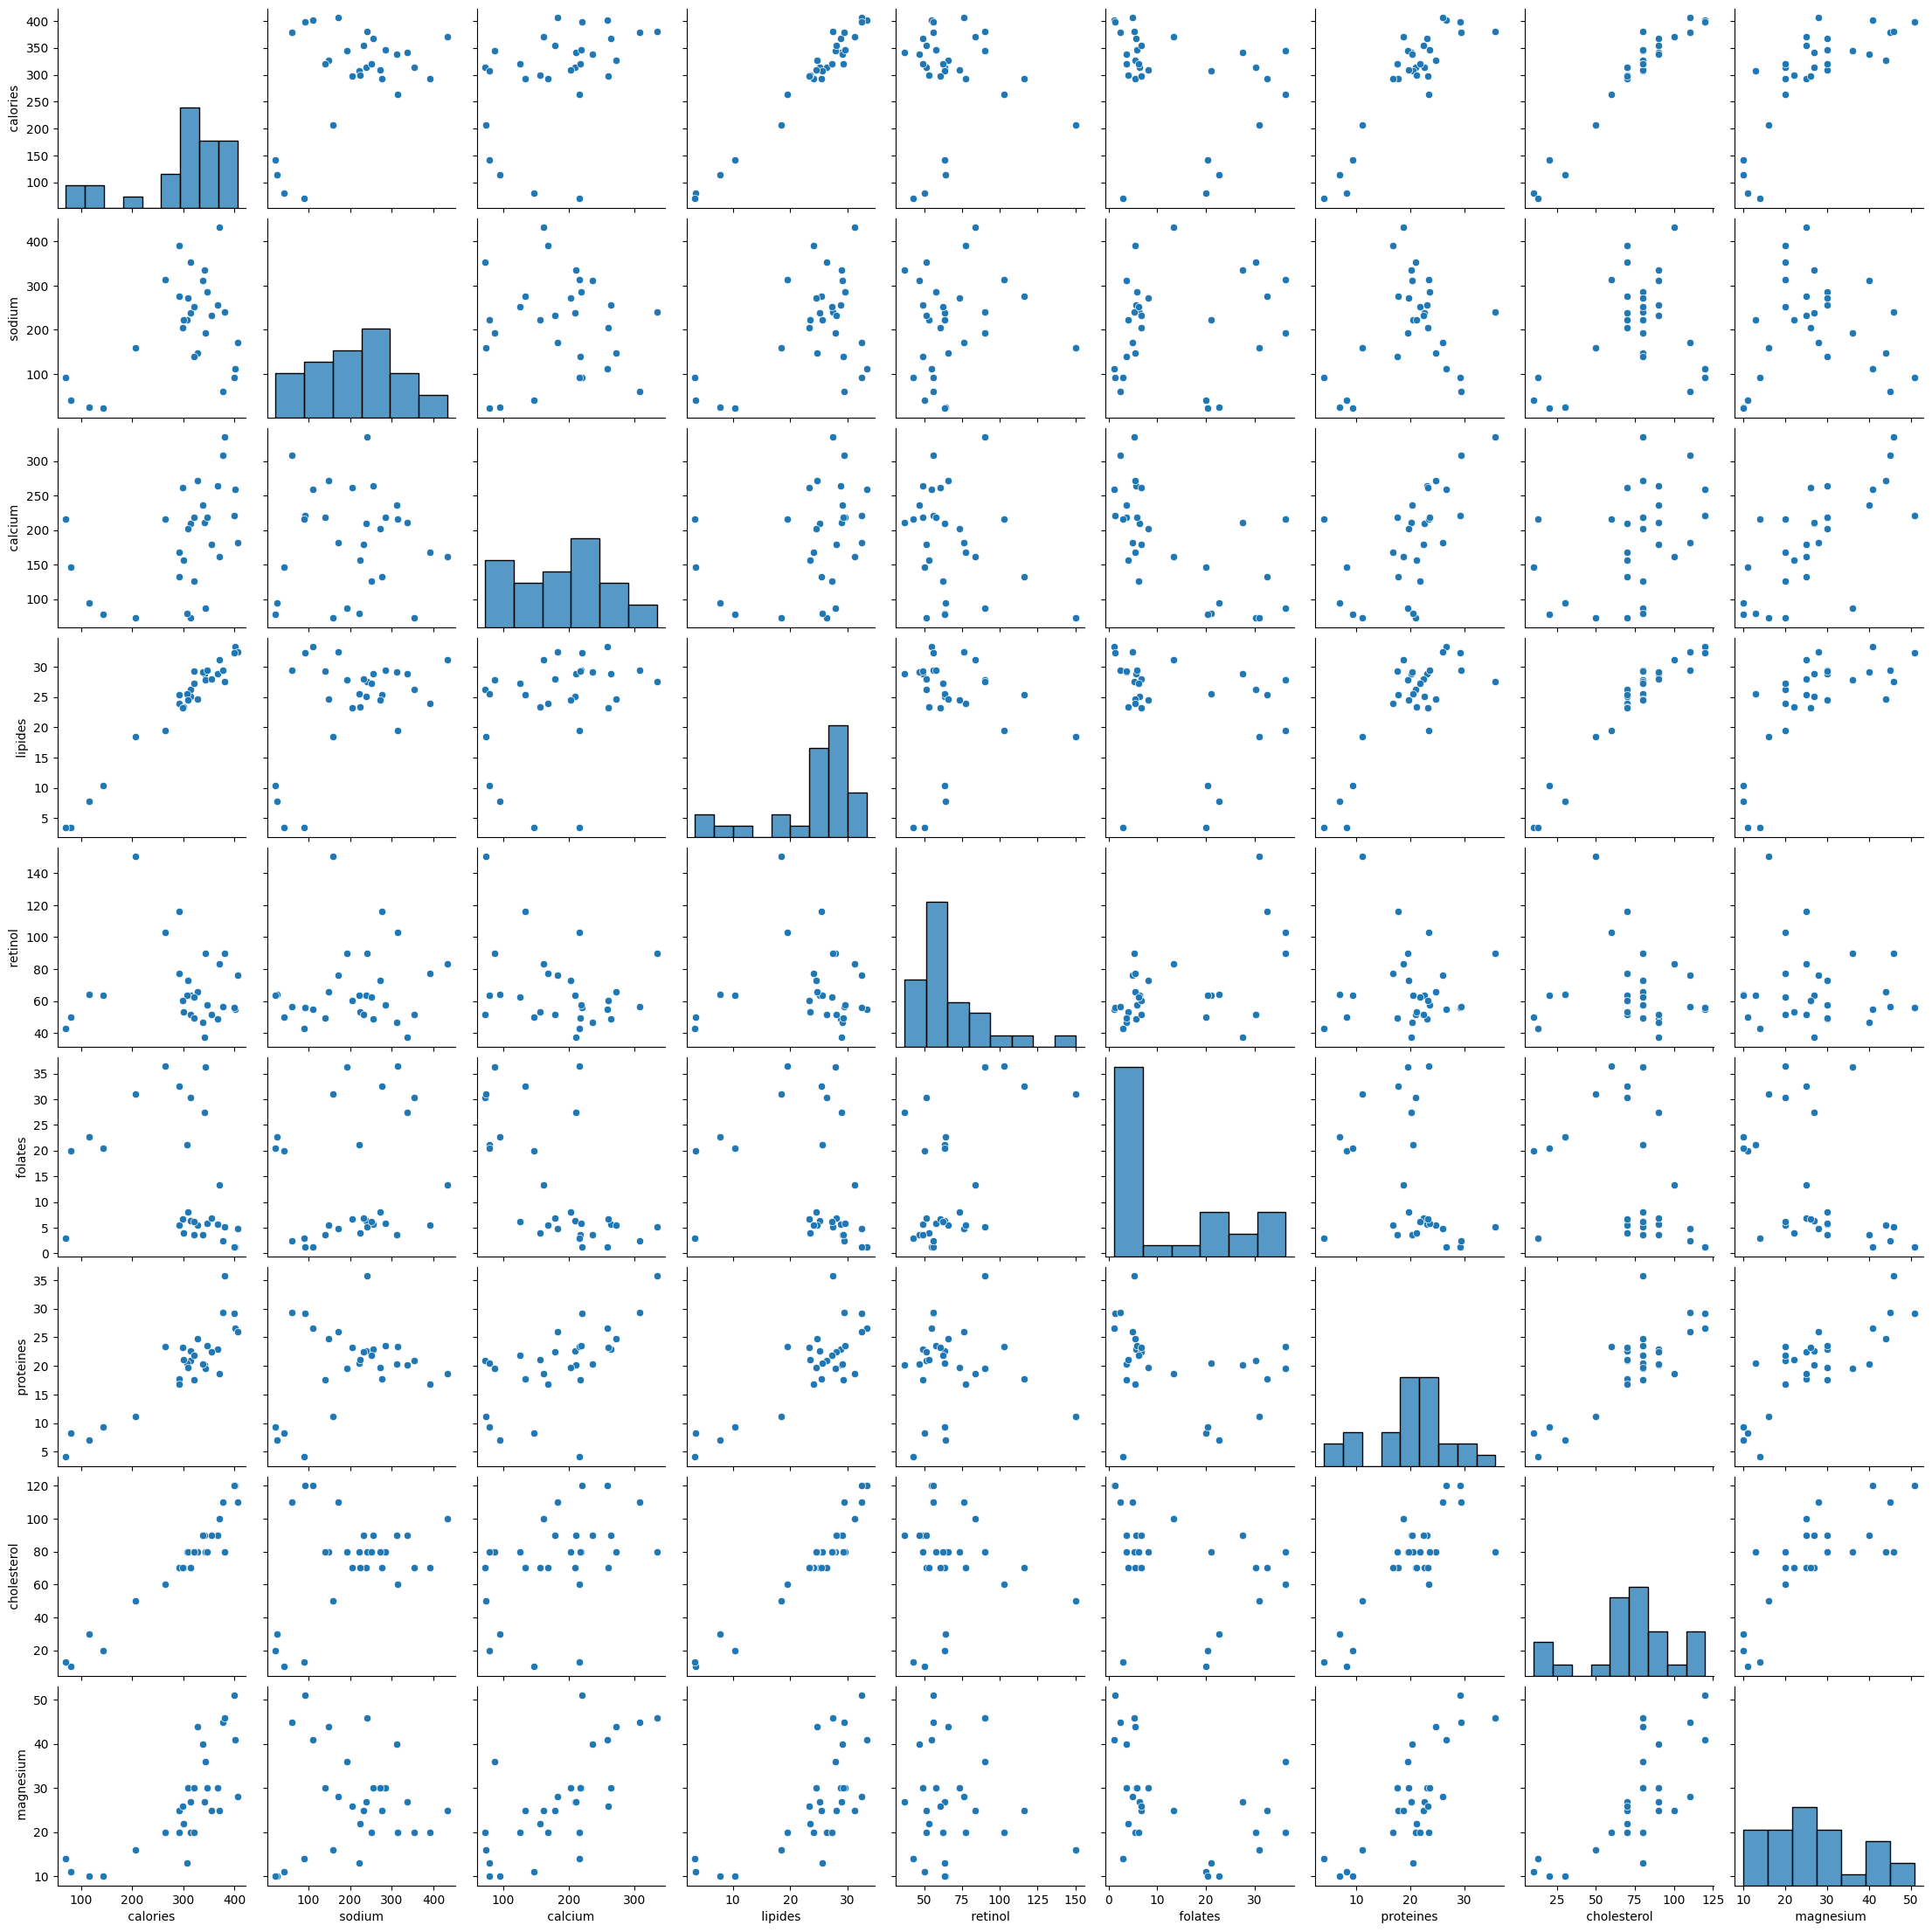

In [5]:
# c) Pairplot — variables corrélées
sns.pairplot(fromage)
plt.show()


**Identifiez les variables corrélées en observant les nuages de points.**  
> On peut remarquer une bonne corrélation entre les variables:  
> - `cholesterol` et `calories`
> - `cholesterol` et `lipides`
> - `calories` et `lipides`

## 1.2 CAH — Classification Ascendante Hiérarchique

La CAH est **ascendante** : elle part de chaque individu seul dans sa classe, puis regroupe progressivement en classes de plus en plus grandes.  
On utilise ici la **méthode de Ward** (minimisation de l'inertie intra-classe) avec la distance euclidienne.

In [6]:
rcParams['figure.figsize'] = 8, 10
Z = linkage(fromage, method='ward',metric='euclidean')
# On affiche le dendrogramme
plt.title("CAH")
dendrogram(Z, labels=fromage.index, orientation='left', color_threshold=0)
plt.show()

ValueError: could not convert string to float: 'CarredelEst '

### À vous !

**a) Quel découpage vous semble optimal (justifiez) ?**

> Pour déterminer le découpage le plus optimal, on doit analyser le dendogramme et plus particulièrement identifier le saut de distance le plus grand.  
Visuellement dans notre dendogramme, cela correspond à aux ensembles avant `Camembert` et ceux après `Camembert`

---

**b) Découpage en 4 groupes — identification et description des caractéristiques**

In [ ]:
# On découpe le dendogramme en 4 groupes
fromage['groupe_CAH'] = fcluster(Z, 4, criterion='maxclust')
# On stocke les groupes de fromages dans une liste pour pouvoir les comparer par la suite avec la méthode centroid
groupes = [fromage[fromage['groupe_CAH'] == g].index.tolist() for g in sorted(fromage['groupe_CAH'].unique())]
# On affiche les groupes et leurs éléments
for g, membres in enumerate(groupes, start=1):
    print(f"Groupe {g} : {membres}")

# On affiche les describe() de chaque groupes
for g, membres in enumerate(groupes, start=1):
    print(f"Groupe {g} :")
    print(fromage.loc[membres].describe())
    print("\n")


Groupe 1 : ['Fr.frais20nat. ', 'Fr.frais40nat. ', 'Petitsuisse40 ', 'Yaourtlaitent.nat. ']
Groupe 2 : ['Beaufort ', 'Cantal ', 'Cheddar ', 'Comte ', 'Edam ', 'Emmental ', 'Parmesan ', 'SaintPaulin ', 'Vacherin ']
Groupe 3 : ['CarredelEst ', 'Bleu ', 'Camembert ', 'Fr.fondu.45 ', 'Maroilles ', 'Morbier ', 'Rocquefort ']
Groupe 4 : ['Babybel ', 'Chabichou ', 'Chaource ', 'Coulomniers ', 'Fr.chevrepatemolle ', 'PontlEveque ', 'Pyrenees ', 'Reblochon ', 'Tome ']
Groupe 1 :
        calories     sodium     calcium    lipides    retinol    folates   \
count    4.000000   4.000000    4.000000   4.000000   4.000000   4.000000   
mean   101.750000  44.750000  133.750000   6.275000  55.150000  16.475000   
std     33.049206  31.941353   61.849845   3.430622  10.462154   9.121906   
min     70.000000  22.000000   78.200000   3.400000  42.900000   2.900000   
25%     77.500000  24.250000   90.650000   3.475000  48.225000  15.725000   
50%     97.500000  33.000000  120.550000   5.650000  56.700000  

**c) Essayez un autre paramétrage (méthode de linkage différente) et comparez**

> Ici on va utiliser la **méthode des centroides** vue en cours.


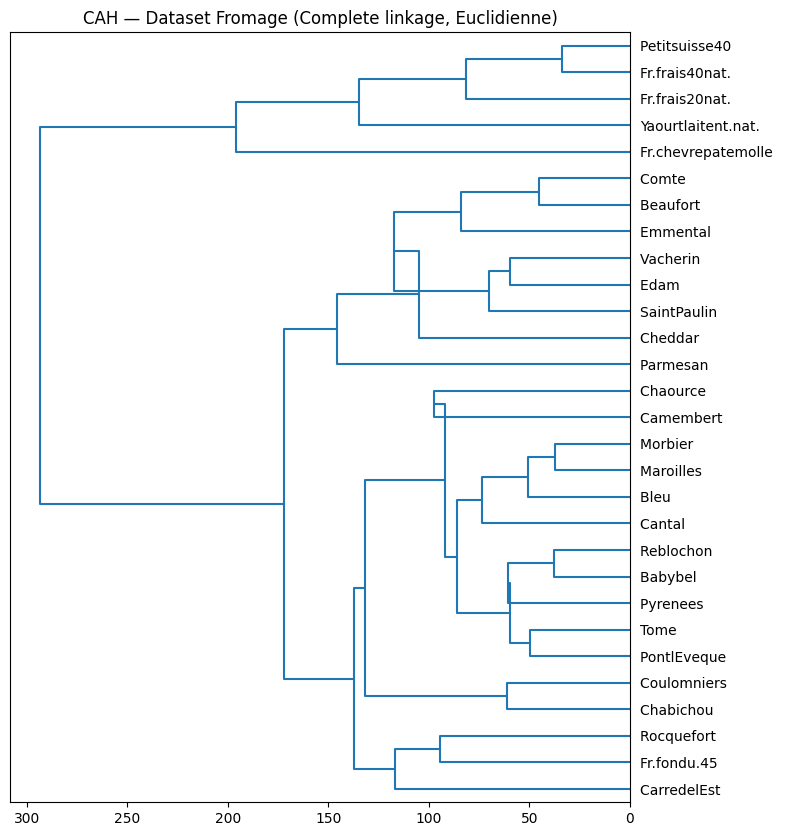

In [ ]:
# c) Autre paramétrage : méthode 'complete' (lien complet)
Z_complete = linkage(fromage.drop(columns=['groupe_CAH']), method='centroid', metric='euclidean')

plt.figure(figsize=(8, 10))
plt.title('CAH — Dataset Fromage (Complete linkage, Euclidienne)')
dendrogram(Z_complete, labels=fromage.index, orientation='left', color_threshold=0)
plt.tight_layout()
plt.show()

# Comparez avec le modèle Ward — les groupes sont-ils différents ?

In [ ]:
# On compare les groupes obtenus avec la méthode centroid avec ceux obtenus avec la méthode Ward
groupes_centroid = [fromage[fromage['groupe_CAH'] == g].index.tolist() for g in sorted(fromage['groupe_CAH'].unique())]
for g, membres in enumerate(groupes_centroid, start=1):
    print(f"Groupe {g} (Centroid) : {membres}")
print(f"\nLes groupes sont les mêmes ? {groupes == groupes_centroid}")

Groupe 1 (Centroid) : ['Fr.frais20nat. ', 'Fr.frais40nat. ', 'Petitsuisse40 ', 'Yaourtlaitent.nat. ']
Groupe 2 (Centroid) : ['Beaufort ', 'Cantal ', 'Cheddar ', 'Comte ', 'Edam ', 'Emmental ', 'Parmesan ', 'SaintPaulin ', 'Vacherin ']
Groupe 3 (Centroid) : ['CarredelEst ', 'Bleu ', 'Camembert ', 'Fr.fondu.45 ', 'Maroilles ', 'Morbier ', 'Rocquefort ']
Groupe 4 (Centroid) : ['Babybel ', 'Chabichou ', 'Chaource ', 'Coulomniers ', 'Fr.chevrepatemolle ', 'PontlEveque ', 'Pyrenees ', 'Reblochon ', 'Tome ']

Les groupes sont les mêmes ? True


> On remarque que les groupes sont les même pour la méthode de Ward et des centroïdes.

---
# 2. Iris

## 2.1 Chargement des données

Le jeu de données **Iris** (UCI Machine Learning Repository, 1936) contient **150 instances** de fleurs d'iris, décrites par 4 attributs :
- `SepalLengthCm`, `SepalWidthCm` (longueur et largeur du sépale)
- `PetalLengthCm`, `PetalWidthCm` (longueur et largeur du pétale)

Il existe **3 espèces** : *Iris setosa*, *Iris versicolor*, *Iris virginica*.  
Pas de valeurs manquantes.

In [8]:
# a) Chargez les données dans une variable appelée iris
iris = pd.read_csv('Iris.csv', index_col='Id')
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
# b) Écart-type, min, max, quartiles
iris.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


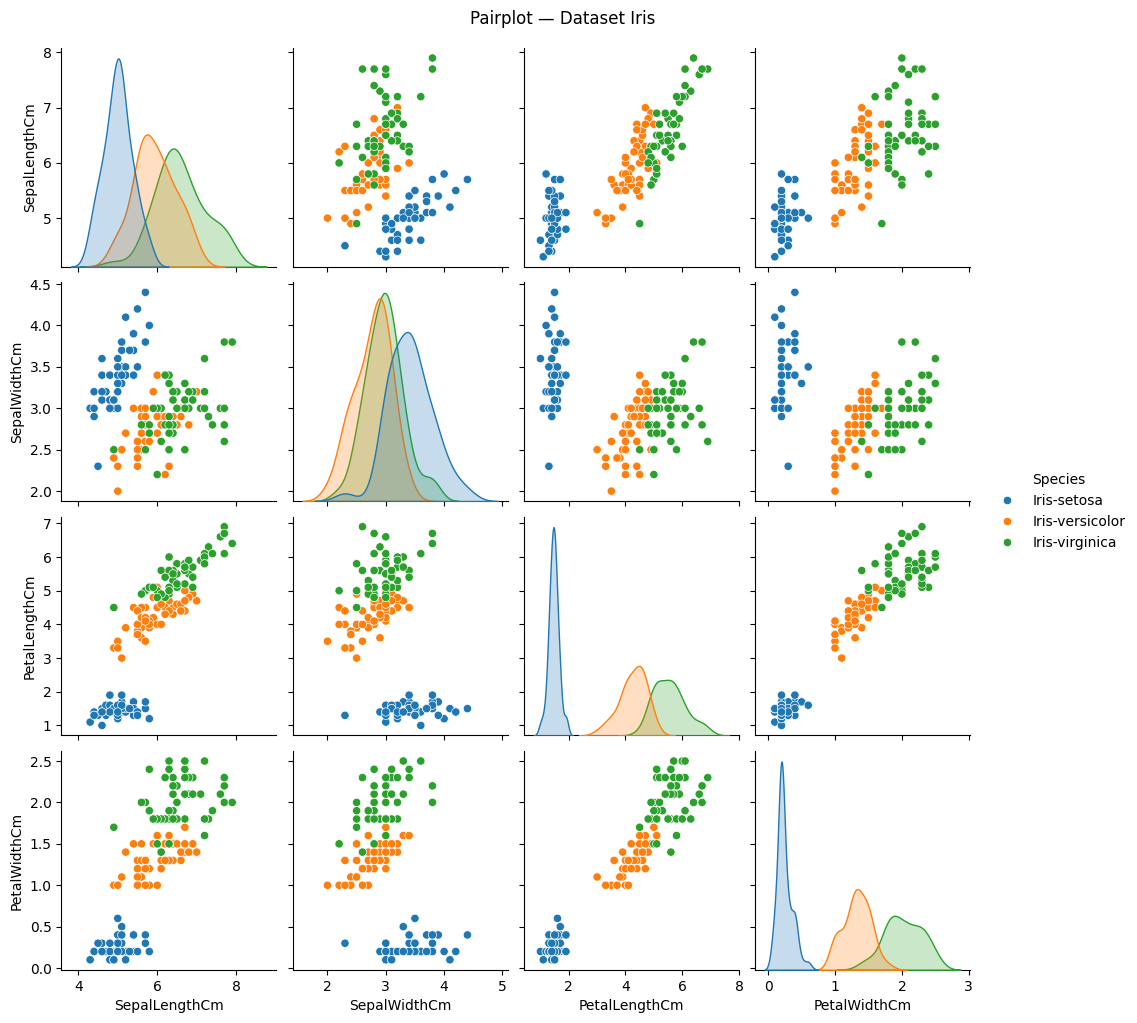

In [10]:
# c) Pairplot coloré par espèce — variables corrélées
sns.pairplot(iris, hue='Species')
plt.suptitle('Pairplot — Dataset Iris', y=1.02)
plt.show()

> On remarque les variables corrélées:
> - `PetalWidthCm` et `PetalLengthCm`
> - `SepalLengthCm` et `PetalLengthCm` (en expluant les données de `Iris-setosa`)

## 2.2 K-means

K-means choisit aléatoirement des barycentres initiaux puis les recalcule itérativement.  
Il nécessite de fixer le nombre de clusters **k** à l'avance (hyperparamètre).

Commençons avec **k = 2**.

In [11]:
random.seed(10)

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# K-means avec k=2
model = KMeans(n_clusters=2, random_state=0)
model.fit(iris[features])

res_label = model.labels_
print(res_label)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [12]:
# Ajout de la colonne de cluster au dataframe
iris.insert(5, "kmeansClass", model.labels_, True)
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,kmeansClass
Id,,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa,0
2,4.9,3.0,1.4,0.2,Iris-setosa,0
3,4.7,3.2,1.3,0.2,Iris-setosa,0
4,4.6,3.1,1.5,0.2,Iris-setosa,0
5,5.0,3.6,1.4,0.2,Iris-setosa,0


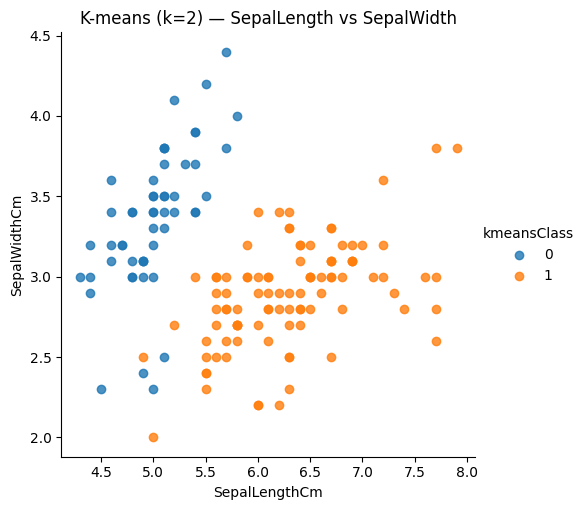

In [13]:
# Scatter plot coloré par classe kmeans
sns.lmplot(x='SepalLengthCm', y='SepalWidthCm', data=iris,
           hue='kmeansClass', fit_reg=False)
plt.title('K-means (k=2) — SepalLength vs SepalWidth')
plt.show()

### À vous !

**a) K-means peut-il utiliser des variables catégorielles ? Pourquoi ?**

> K-means repose sur le calcul de **distances euclidiennes** entre points numériques. Les variables catégorielles n'ont pas de notion de distance directe, donc K-means ne peut pas les utiliser directement sans encodage préalable.

---

**b) Scatter plot coloré par vraie espèce — comparer avec k=2**

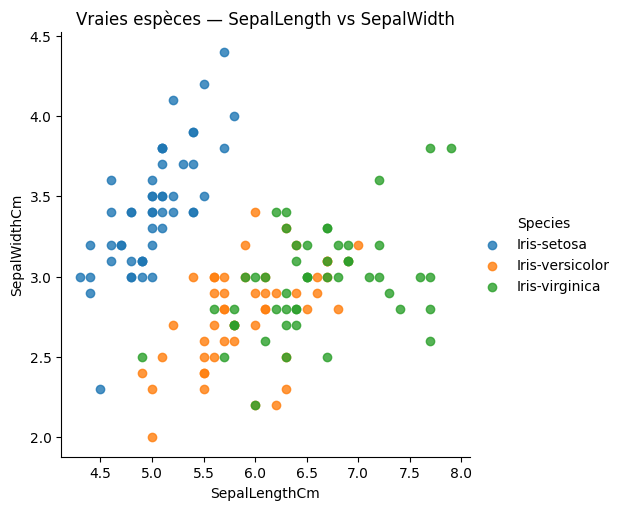

In [14]:
# b) Scatter plot avec la vraie variable Species
sns.lmplot(x='SepalLengthCm', y='SepalWidthCm', data=iris,
           hue='Species', fit_reg=False)
plt.title('Vraies espèces — SepalLength vs SepalWidth')
plt.show()

> On remarque 3 espèces d'iris dans le jeu de données.

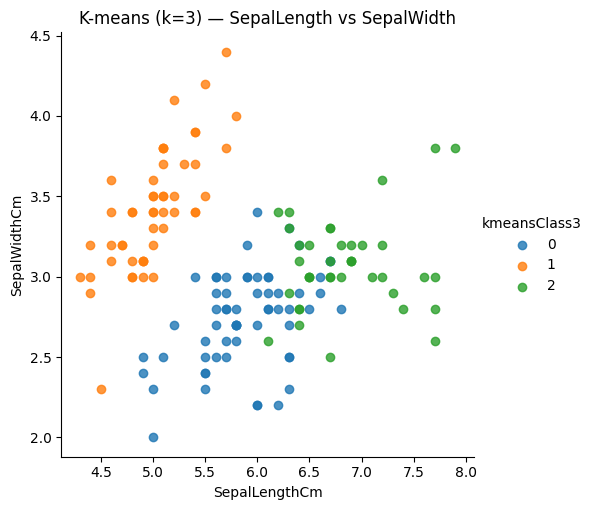

In [15]:
# c) K-means avec le vrai nombre d'espèces (k=3)
model3 = KMeans(n_clusters=3, random_state=0)
model3.fit(iris[features])

iris['kmeansClass3'] = model3.labels_

sns.lmplot(x='SepalLengthCm', y='SepalWidthCm', data=iris,
           hue='kmeansClass3', fit_reg=False)
plt.title('K-means (k=3) — SepalLength vs SepalWidth')
plt.show()

In [16]:
# d) Comparaison clustering vs vraies espèces avec crosstab
ct = pd.crosstab(iris['Species'], iris['kmeansClass3'],
                 rownames=['Vraie espèce'], colnames=['Cluster K-means'])
print(ct)

Cluster K-means   0   1   2
Vraie espèce               
Iris-setosa       0  50   0
Iris-versicolor  47   0   3
Iris-virginica   14   0  36


> De façon visuelle, on peut déjà remarquer que les cluster 0 et 2 sont en difficultés.
En utilisant `crosstab`, on confirme bien que ses cluster sont en difficultés, les distinctions dans ses cluster ne sont pas aussi bonne que le cluster 1.

## 2.3 Nombre de classes — Méthode du coude (Elbow Method)

K-means ne fournit pas d'outil automatique pour choisir k.  
On observe l'évolution du **WCSS** (Within Cluster Sum of Squares) en fonction de k et on cherche le "coude" dans la courbe.

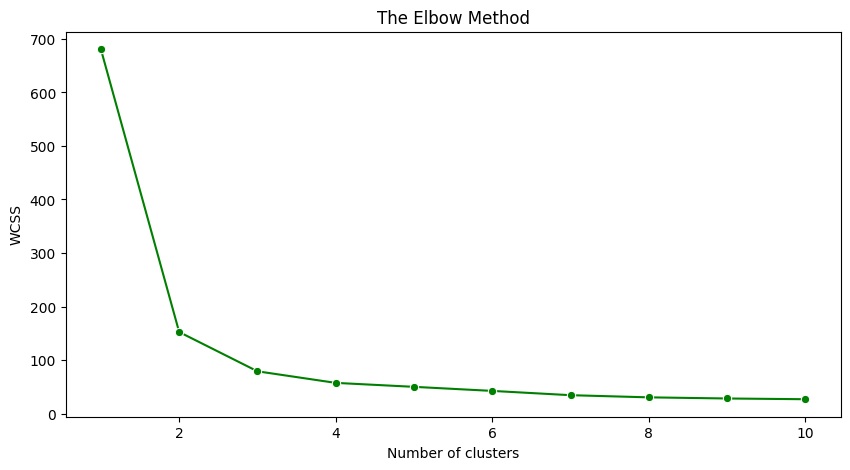

In [17]:
# Calcul du WCSS pour k de 1 à 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(iris[features])
    wcss.append(kmeans.inertia_)

# Tracé de la courbe du coude
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='green')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### À vous !

**a) Conclure sur le nombre k à fixer**

> On remarque que le coude est situé à $k=2$, cela signifie donc que le nombre de clusters optimal est 2.

---

**b) Réalisez une CAH sur Iris et comparez avec K-means via une matrice de confusion**

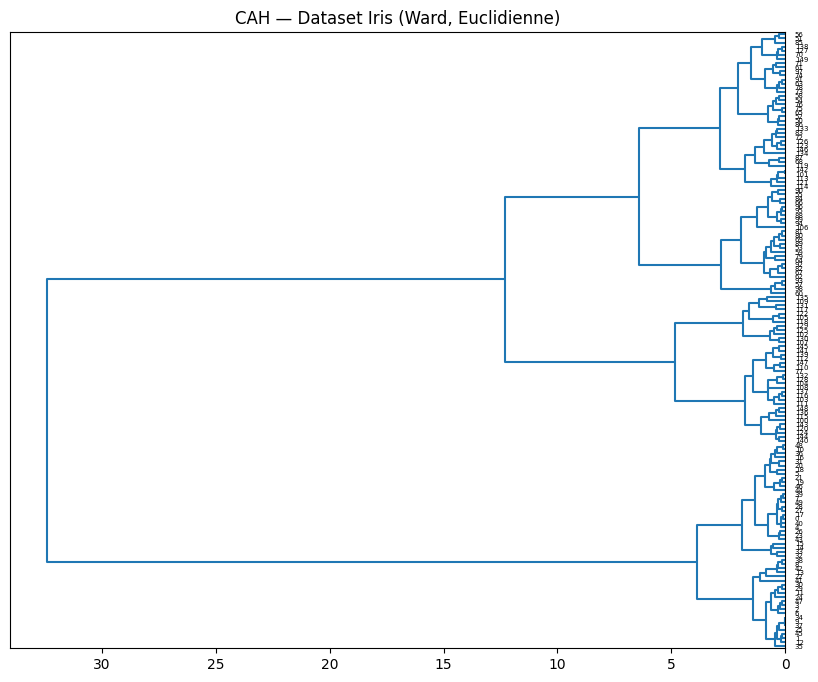

In [18]:
# b) CAH sur le dataset Iris
rcParams['figure.figsize'] = 10, 8

Z_iris = linkage(iris[features], method='ward', metric='euclidean')

plt.title('CAH — Dataset Iris (Ward, Euclidienne)')
dendrogram(Z_iris, orientation='left', color_threshold=0)
plt.show()

Matrice de confusion (CAH vs K-means):
K-means (k=3)     0   1   2
CAH (3 groupes)            
1                 0  50   0
2                 0   0  36
3                61   0   3




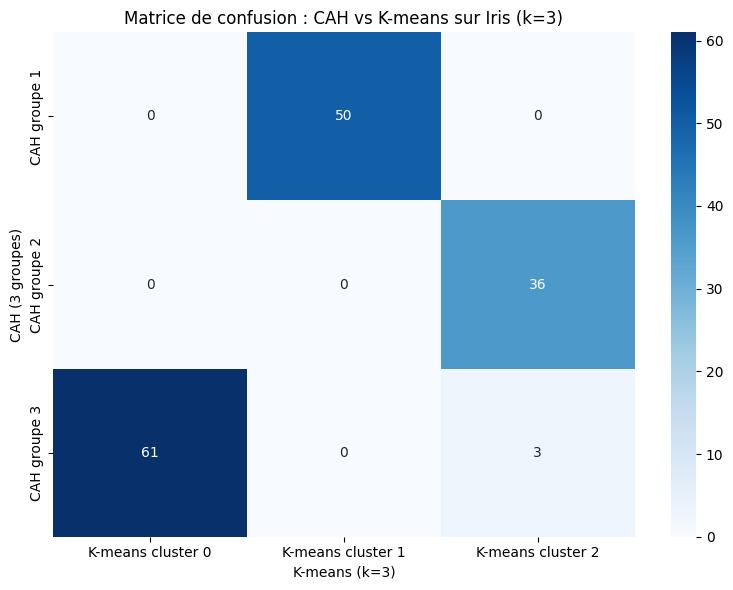

In [21]:
# Découpage en 3 groupes avec fcluster
cah_labels = fcluster(Z_iris, t=3, criterion='maxclust')
iris['CAH_label'] = cah_labels

# Matrice de confusion CAH vs K-means (crosstab)
confusion = pd.crosstab(iris['CAH_label'], iris['kmeansClass3'],
                        rownames=['CAH (3 groupes)'], colnames=['K-means (k=3)'])
print("Matrice de confusion (CAH vs K-means):")
print(confusion)
print("\n")

# Visualisation de la matrice de confusion avec heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['K-means cluster 0', 'K-means cluster 1', 'K-means cluster 2'],
            yticklabels=['CAH groupe 1', 'CAH groupe 2', 'CAH groupe 3'])
plt.title('Matrice de confusion : CAH vs K-means sur Iris (k=3)')
plt.xlabel('K-means (k=3)')
plt.ylabel('CAH (3 groupes)')
plt.tight_layout()
plt.show()


**c) Conclusions — Différences entre CAH et K-means sur le dataset Iris**

> 

---

# 3. Pour aller plus loin

- [Implémentation K-means en Python](https://hands-on.cloud/implementation-of-k-means-clustering-algorithm-using-python/)
- Documentation `scipy.cluster.hierarchy` : `linkage`, `dendrogram`, `fcluster`